# 🧬 TP 4 : comparer RNN, LSTM et GRU sur une dépendance longue

**Durée indicative : 2 h 30 — Les résultats sont empiriques et dépendent de l'optimisation.**

## Objectifs observables

1. construire une tâche où la cible dépend d'un signal ancien ;
2. comparer trois architectures avec les mêmes données et le même budget ;
3. mesurer MSE de test et nombre de paramètres ;
4. conclure à partir des sorties observées, sans supposer qu'une architecture gagne toujours.


## 1. Imports et Initialisation


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Calcul exécuté sur : {device}")


Calcul exécuté sur : mps


## 2. Une tâche synthétique à dépendance longue

Chaque séquence contient 60 pas. Un signal informatif est placé au pas 2 et la cible finale en dépend. Le bruit des pas suivants rend sa conservation difficile.

Ce montage **favorise l'étude** du mécanisme de mémoire ; il ne prouve pas une supériorité générale du LSTM sur toutes les séries temporelles.


In [2]:
def generate_memory_data(n_samples=1500, seq_len=60):
    # Séquences de bruit gaussien
    X = np.random.randn(n_samples, seq_len, 1) * 0.2
    
    # Injection d'un marqueur informatif au début (entre t=2 et t=4)
    trigger_values = np.random.uniform(-1.0, 1.0, size=(n_samples, 1))
    X[:, 2, 0] = trigger_values[:, 0]
    
    # La cible finale est une transformation non-linéaire de ce déclencheur initial
    y = np.sin(trigger_values * np.pi)
    
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X, y = generate_memory_data(n_samples=2000, seq_len=60)
X_train, X_test = X[:1500], X[1500:]
y_train, y_test = y[:1500], y[1500:]

print(f"Forme de X_train : {X_train.shape} (Lots, Longueur_Séquence, Features)")
print(f"Forme de y_train : {y_train.shape}")


Forme de X_train : torch.Size([1500, 60, 1]) (Lots, Longueur_Séquence, Features)
Forme de y_train : torch.Size([1500, 1])


## 3. Définition des Deux Modèles Comparatifs

> 🔍 **La Différence Clé PyTorch entre `nn.RNN` et `nn.LSTM`** :
>- `nn.RNN` renvoie `(output, h_n)` : un seul vecteur de mémoire cachée.
>- `nn.LSTM` renvoie `(output, (h_n, c_n))` : deux mémoires distinctes !
>  - `h_n` : L'état caché (*Short-Term Memory*), utilisé pour la prédiction immédiate.
>  - `c_n` : L'état cellulaire (*Long-Term Memory*), le carnet de notes qui traverse le temps.

In [3]:
class BaselineRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        # Le LSTM renvoie (out, (h_n, c_n))
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.fc(out[:, -1, :])

model_rnn = BaselineRNN().to(device)
model_lstm = LSTMPredictor().to(device)

print("Modèles RNN et LSTM initialisés.")


Modèles RNN et LSTM initialisés.


## 4. Entraînement Comparatif


In [4]:
def train_sequence_model(model, X_tr, y_tr, epochs=40, lr=0.005):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = []
    
    dataset = torch.utils.data.TensorDataset(X_tr, y_tr)
    loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * batch_x.size(0)
        history.append(epoch_loss / len(X_tr))
    return history

print("Entraînement du Vanilla RNN...")
loss_rnn = train_sequence_model(model_rnn, X_train, y_train, epochs=40)

print("Entraînement du LSTM...")
loss_lstm = train_sequence_model(model_lstm, X_train, y_train, epochs=40)
print("Entraînements terminés !")


Entraînement du Vanilla RNN...


Entraînement du LSTM...


Entraînements terminés !


## 5. Comparaison des résultats observés

Les courbes suivantes décrivent cette graine, ce budget d'entraînement et cette tâche. Une comparaison plus robuste répéterait l'expérience avec plusieurs graines et présenterait moyenne et dispersion.


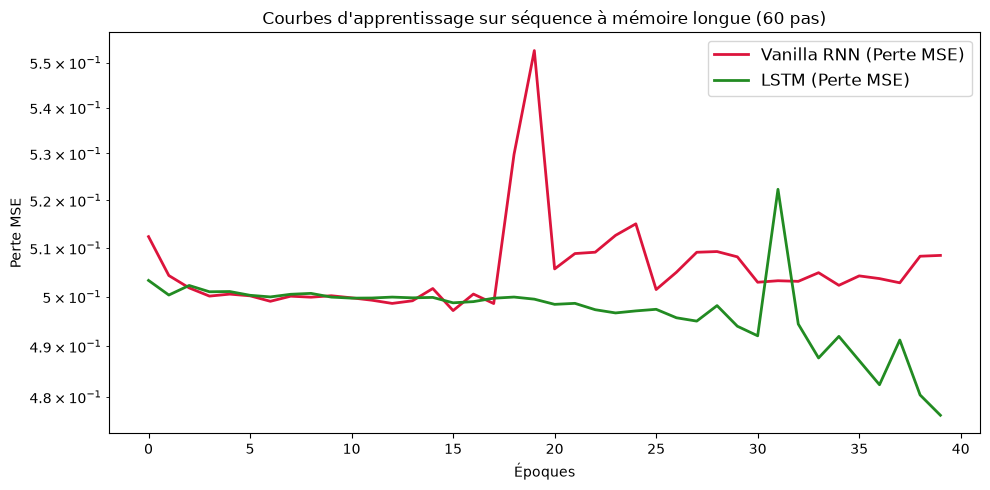

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(loss_rnn, label="Vanilla RNN (Perte MSE)", color='crimson', lw=2)
plt.plot(loss_lstm, label="LSTM (Perte MSE)", color='forestgreen', lw=2)
plt.title("Courbes d'apprentissage sur séquence à mémoire longue (60 pas)")
plt.xlabel("Époques")
plt.ylabel("Perte MSE")
plt.legend(fontsize=12)
plt.yscale('log')
plt.tight_layout()
plt.show()


Évaluons la corrélation entre les prédictions et la réalité sur le jeu de test :


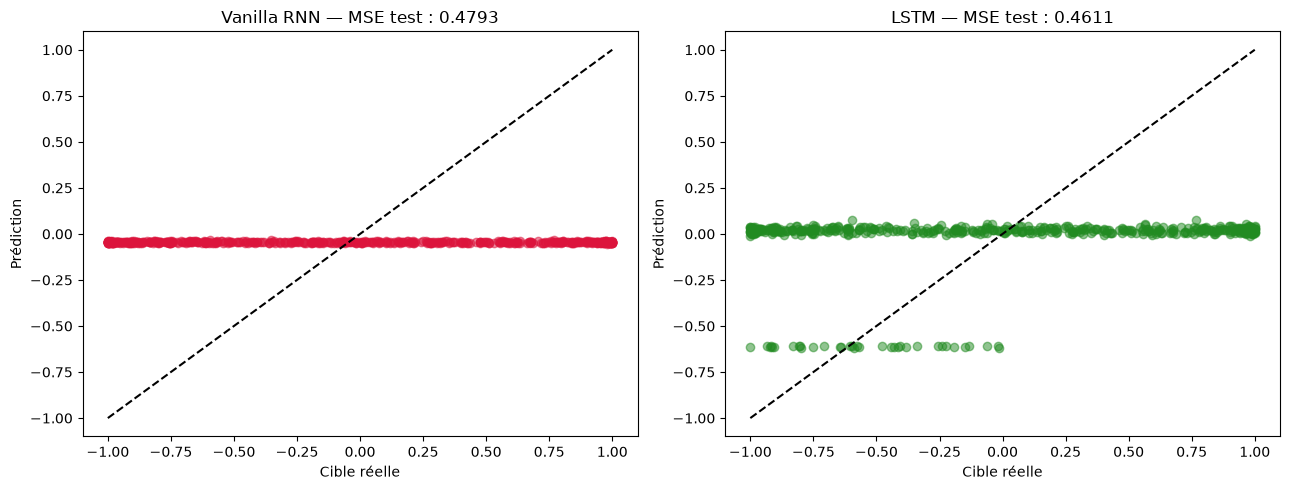

{'RNN': 0.47933825850486755, 'LSTM': 0.4611203372478485}


In [6]:
model_rnn.eval()
model_lstm.eval()

with torch.no_grad():
    pred_rnn = model_rnn(X_test.to(device)).cpu().numpy()
    pred_lstm = model_lstm(X_test.to(device)).cpu().numpy()
    y_true = y_test.numpy()

mse_rnn = float(np.mean((pred_rnn - y_true) ** 2))
mse_lstm = float(np.mean((pred_lstm - y_true) ** 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for axis, predictions, title, color, mse in [
    (axes[0], pred_rnn, "Vanilla RNN", 'crimson', mse_rnn),
    (axes[1], pred_lstm, "LSTM", 'forestgreen', mse_lstm),
]:
    axis.scatter(y_true, predictions, alpha=0.5, color=color)
    axis.plot([-1, 1], [-1, 1], 'k--')
    axis.set_title(f"{title} — MSE test : {mse:.4f}")
    axis.set_xlabel("Cible réelle")
    axis.set_ylabel("Prédiction")
plt.tight_layout()
plt.show()

print({"RNN": mse_rnn, "LSTM": mse_lstm})


Interprétez les nuages et les MSE imprimées ci-dessus. Si le LSTM gagne, le résultat est cohérent avec son biais inductif pour conserver l'information ; s'il ne gagne pas, examinez optimisation, graine et difficulté de la tâche au lieu de réécrire la conclusion à l'avance.


## 6. Exercice guidé : le GRU

Le GRU utilise trois transformations de portes là où le LSTM en utilise quatre. À tailles d'entrée et d'état caché égales, il comporte donc généralement environ 25 % de paramètres récurrents en moins — la proportion exacte dépend aussi des couches de sortie.

Implémentez un GRU, entraînez-le avec le même protocole, puis comparez MSE de test **et** nombre de paramètres.


In [7]:
# À vous de jouer.
# TODO : définir BaselineGRU, l'entraîner et calculer sa MSE de test.


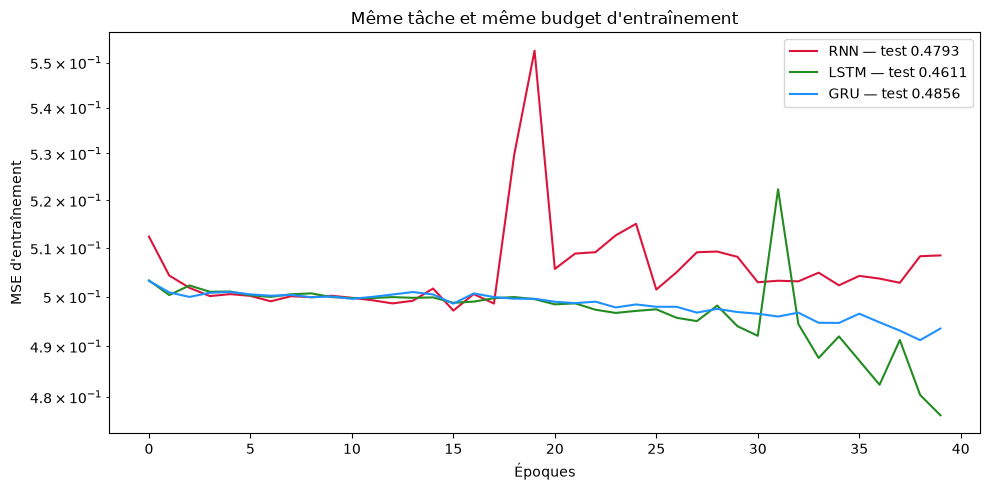

MSE test : {'RNN': 0.47933825850486755, 'LSTM': 0.4611203372478485, 'GRU': 0.4855540096759796}
Paramètres : {'RNN': 1153, 'LSTM': 4513, 'GRU': 3393}


In [8]:
class BaselineGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=32):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.gru(x)
        return self.fc(output[:, -1, :])


torch.manual_seed(42)
model_gru = BaselineGRU().to(device)
loss_gru = train_sequence_model(model_gru, X_train, y_train, epochs=40)
model_gru.eval()
with torch.no_grad():
    pred_gru = model_gru(X_test.to(device)).cpu().numpy()
mse_gru = float(np.mean((pred_gru - y_true) ** 2))

parameter_counts = {
    "RNN": sum(parameter.numel() for parameter in model_rnn.parameters()),
    "LSTM": sum(parameter.numel() for parameter in model_lstm.parameters()),
    "GRU": sum(parameter.numel() for parameter in model_gru.parameters()),
}

plt.figure(figsize=(10, 5))
plt.plot(loss_rnn, label=f"RNN — test {mse_rnn:.4f}", color='crimson')
plt.plot(loss_lstm, label=f"LSTM — test {mse_lstm:.4f}", color='forestgreen')
plt.plot(loss_gru, label=f"GRU — test {mse_gru:.4f}", color='dodgerblue')
plt.yscale('log')
plt.xlabel("Époques")
plt.ylabel("MSE d'entraînement")
plt.title("Même tâche et même budget d'entraînement")
plt.legend()
plt.tight_layout()
plt.show()

print("MSE test :", {"RNN": mse_rnn, "LSTM": mse_lstm, "GRU": mse_gru})
print("Paramètres :", parameter_counts)
assert parameter_counts["GRU"] < parameter_counts["LSTM"]
assert np.isfinite([mse_rnn, mse_lstm, mse_gru]).all()


## Conclusion et auto-évaluation

- Les portes du LSTM et du GRU facilitent le contrôle de l'information, sans garantir une victoire sur toute tâche.
- Une comparaison d'architectures doit fixer données, graine, budget et métrique.
- Le nombre de paramètres éclaire le compromis capacité/coût mais ne remplace pas la mesure de test.
- Une expérience plus solide répéterait plusieurs graines et rapporterait la dispersion.
